In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

Loading Gene Summary...
Target Hits Found: 262
Loading Combined Data...
Processing Rep 1...
Processing Rep 2...
Processing Rep 3...
Processing Rep 4...


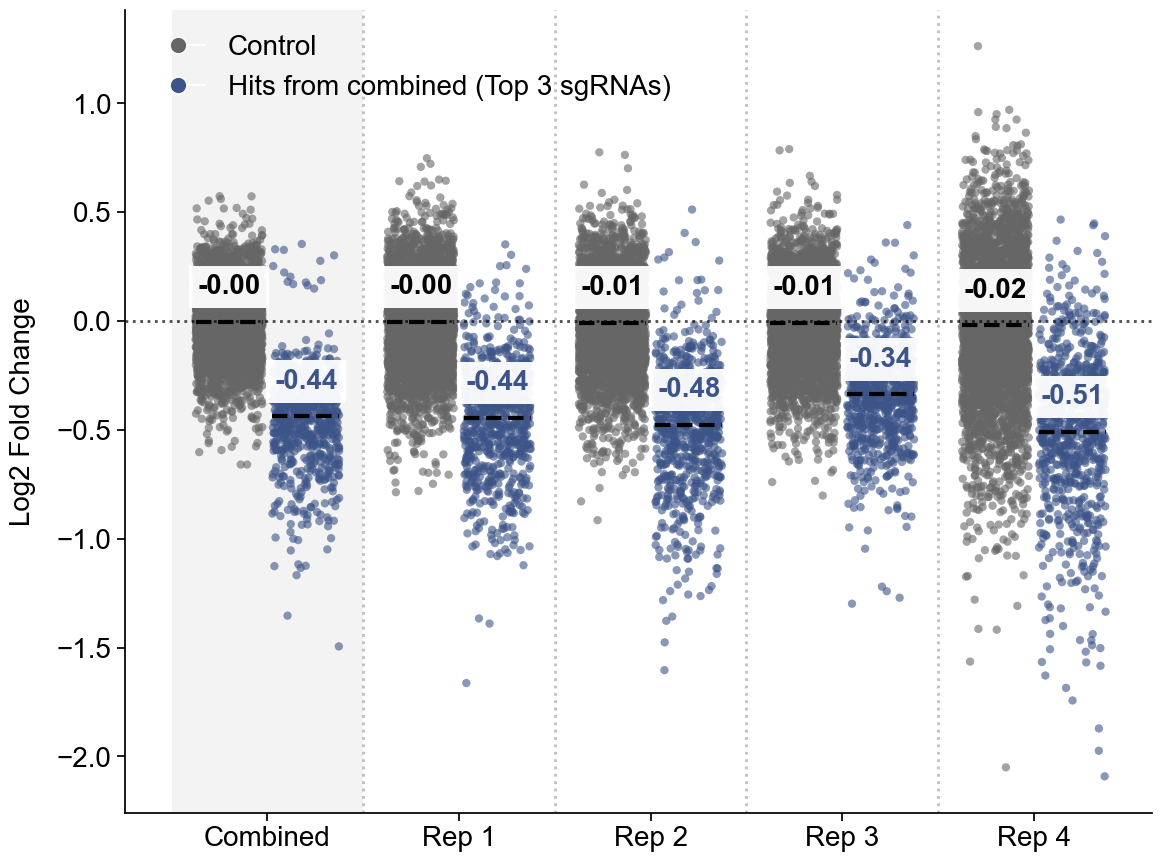

In [8]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# 1. CONFIGURATION
# ==========================================

# A. File Paths
combined_file_path = "../new_mageck/Syn1-GW-all_4M/Syn1-GW-all_4M.sgrna_summary.txt"
gene_summary_path = "../new_mageck/Syn1-GW-all_4M/Syn1-GW-all_4M.gene_summary.txt"
replicate_file_path = "../roc_auc/mageck_output/"

replicate_files = {}

# Dynamic Replicate Discovery
i = 1
if os.path.exists(replicate_file_path):
    sorted_files = sorted(os.listdir(replicate_file_path))
    for name in sorted_files:
        if name.startswith('Syn1-GW-4M'):
            full_path = os.path.join(replicate_file_path, name, f'{name}.sgrna_summary.txt')
            if os.path.exists(full_path):
                replicate_files[f'Rep {i}'] = full_path
                i += 1
else:
    print(f"WARNING: Directory {replicate_file_path} not found.")

# B. Hit Selection
print("Loading Gene Summary...")
df_gene_summary = pd.read_csv(gene_summary_path, sep='\t')

target_genes = df_gene_summary[df_gene_summary['hits'] == -1]['id'].tolist()
print(f"Target Hits Found: {len(target_genes)}")

# ==========================================
# 2. DATA PROCESSING
# ==========================================

def load_mageck_file(filepath):
    return pd.read_csv(filepath, sep='\t')

print("Loading Combined Data...")
df_combined = load_mageck_file(combined_file_path)

# --- Step A: Identify Hit sgRNAs ---
hits = target_genes
hits_df = df_combined[df_combined['Gene'].isin(hits)].copy()

sort_col = 'score' if 'score' in hits_df.columns else 'LFC'
ascending_logic = False if sort_col == 'score' else True

top_sgrnas_ids = hits_df.sort_values(sort_col, ascending=ascending_logic).groupby('Gene').head(3)['sgrna'].tolist()

ntc_mask = df_combined['Gene'].str.startswith('non-targeting', na=False)
ntc_sgrnas = df_combined[ntc_mask]['sgrna'].tolist()

# --- Step C: Build Plotting Dataset ---
plot_data = []

def process_file(df, condition_name):
    # 1. Hits
    subset_hits = df[df['sgrna'].isin(top_sgrnas_ids)].copy()
    subset_hits['Type'] = 'Hit' 
    
    # 2. NTCs
    subset_ntc = df[df['sgrna'].isin(ntc_sgrnas)].copy()
    subset_ntc['Type'] = 'NTC'
    
    combined_subset = pd.concat([subset_hits, subset_ntc])
    
    for _, row in combined_subset.iterrows():
        plot_data.append({
            'Gene': row['Gene'],
            'Condition': condition_name,
            'LFC': row['LFC'],
            'Type': row['Type']
        })

process_file(df_combined, 'Combined')

for rep_name, rep_path in replicate_files.items():
    print(f"Processing {rep_name}...")
    df_rep = load_mageck_file(rep_path)
    process_file(df_rep, rep_name)

df_plot = pd.DataFrame(plot_data)

# ==========================================
# 3. PLOTTING (CELL PAPER STYLE)
# ==========================================

# -- Style Settings --
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 20  # Base font size
plt.rcParams['axes.linewidth'] = 2.5 
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8

sns.set_context("notebook", font_scale=1.6) 
plt.figure(figsize=(12, 9))  # Slightly larger figure to accommodate large fonts

conditions_order = ['Combined'] + sorted(replicate_files.keys())

colors = {
    'NTC': '#666666',    # Slate Grey
    'Hit': '#3C5488FF'     # Pumpkin Orange
}

# --- BACKGROUND SHADING ---
plt.axvspan(-0.5, 0.5, facecolor='#f0f0f0', alpha=0.8, zorder=0)

# 1. The Strip Plot
ax = sns.stripplot(
    x='Condition', 
    y='LFC', 
    data=df_plot, 
    hue='Type',
    hue_order=['NTC', 'Hit'], 
    order=conditions_order,
    dodge=True,    
    jitter=0.35,     
    size=6,          
    palette=colors, 
    alpha=0.6,
    edgecolor='none',
    zorder=1
)

# 2. Draw Mean Lines & Labels (DETERMINISTIC PLACEMENT)
means = df_plot.groupby(['Condition', 'Type'])['LFC'].mean()
width = 0.35
dodge_offset = 0.2  # Standard seaborn offset for 2 hue levels

for i, cond in enumerate(conditions_order):
    
    # --- NTC (Left) ---
    if (cond, 'NTC') in means.index:
        mean_val = means[(cond, 'NTC')]
        x_center = i - dodge_offset
        
        col = 'black'
        bg_col = 'white'
        edge_col = 'None'
        
        # Line
        plt.plot([x_center - width/2, x_center + width/2], [mean_val, mean_val], 
                 color=col, linestyle='--', linewidth=3.0, zorder=5)
        # Label
        ax.text(x_center, mean_val + 0.1, f'{mean_val:.2f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=20, color=col,
                bbox=dict(facecolor=bg_col, edgecolor=edge_col, boxstyle='square,pad=0.3', alpha=0.95),
                zorder=4)

    # --- Hit (Right) ---
    if (cond, 'Hit') in means.index:
        mean_val = means[(cond, 'Hit')]
        x_center = i + dodge_offset
        
        col = '#3C5488FF'
        bg_col = 'white'
        edge_col = 'None'
        
        # Line
        plt.plot([x_center - width/2, x_center + width/2], [mean_val, mean_val], 
                 color='k', linestyle='--', linewidth=3.0, zorder=5)
        # Label
        ax.text(x_center, mean_val + 0.1, f'{mean_val:.2f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=20, color=col,
                bbox=dict(facecolor=bg_col, edgecolor=edge_col, boxstyle='square,pad=0.3', alpha=0.95),
                zorder=4)

# 3. Final Polish
plt.axhline(0, color='black', linestyle=':', linewidth=2.0, alpha=0.7)

for x in range(len(conditions_order) - 1):
    plt.axvline(x + 0.5, color='grey', linestyle=':', linewidth=2, alpha=0.5)

# CONNECTED SPINES
sns.despine(trim=False, offset=0) 
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

plt.ylabel('Log2 Fold Change', fontsize=20, labelpad=15)
plt.xlabel('')
# Explicitly set tick labels to 20
plt.tick_params(axis='both', which='major', labelsize=20)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Control', 
           markerfacecolor=colors['NTC'], markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Hits from combined (Top 3 sgRNAs)', 
           markerfacecolor=colors['Hit'], markersize=12),
]
plt.legend(handles=legend_elements, frameon=False, loc='upper left', fontsize=20)

plt.tight_layout()
plt.savefig('../QC/Syn1-GW-all/Syn1-GW_combined_vs_individual_replicates.pdf')